# Preço do milho no Paraná — fontes e série de referência

Este notebook busca o **preço do milho** em diferentes APIs/fontes públicas, pra completar a
análise econômica: junto com o custo real (SEAB/DERAL, série milho safrinha, notebook `09`) e a
produtividade prevista pelo modelo (`05_inferencias.ipynb`), o preço é o que falta pra calcular
receita e margem.

## Fontes usadas

1. **IPEA Data** (`ipeadata.gov.br`, API OData pública) — hospeda séries históricas mensais da
   **SEAB/DERAL-PR** (Secretaria da Agricultura do Paraná) e da **CONAB**, com décadas de histórico:
   - `DERAL12_PRMI12` — **preço médio recebido pelo agricultor**, milho, R$/60kg, **PR**, mensal
     desde 1990. É a série principal (preço de venda do produtor, o que interessa pra receita).
   - `DERAL12_ATMC12` — preço médio **atacado**, milho, R$/60kg, PR — referência de comparação.
   - `DEPAE12_ATMI12` — preço médio atacado, milho, R$/60kg, **SP** (Conab) — referência de outro
     estado, pra contexto.
2. **CONAB — Portal de Informações Agropecuárias** (`portaldeinformacoes.conab.gov.br`) — arquivo
   de download direto com preços **por município**, mas só a janela recente (2025–2026, não é série
   histórica longa). Útil como checagem mais granular/atual, não pra história.

Os dados já buscados foram salvos em cache no repositório (`ipea_precos_milho_mensal.csv`,
`conab_precos_municipio_milho.csv`) — o notebook tenta buscar ao vivo e cai pro cache se não
houver internet, no mesmo padrão do notebook `07`.

In [1]:
import json
import urllib.request
import urllib.parse
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Preço histórico (IPEA — SEAB/DERAL-PR e Conab)

In [2]:
SERIES_IPEA = {
    "DERAL12_PRMI12": "Recebido pelo agricultor - PR (Seab/Deral)",
    "DERAL12_ATMC12": "Atacado - PR (Seab/Deral)",
    "DEPAE12_ATMI12": "Atacado - SP (Conab)",
}
CACHE_IPEA = Path("ipea_precos_milho_mensal.csv")


def buscar_serie_ipea(codigo):
    url = f"http://www.ipeadata.gov.br/api/odata4/ValoresSerie(SERCODIGO='{codigo}')"
    with urllib.request.urlopen(url, timeout=15) as resp:
        dados = json.load(resp)
    df = pd.DataFrame(dados["value"])[["SERCODIGO", "VALDATA", "VALVALOR"]]
    df["VALDATA"] = pd.to_datetime(df["VALDATA"], utc=True).dt.tz_localize(None)
    df["ano"] = df["VALDATA"].dt.year
    df["mes"] = df["VALDATA"].dt.month
    return df.rename(columns={"SERCODIGO": "sercodigo", "VALVALOR": "valor"})[["sercodigo", "ano", "mes", "valor"]]


def montar_precos_ipea():
    try:
        precos = pd.concat([buscar_serie_ipea(c) for c in SERIES_IPEA], ignore_index=True)
        print("Preços obtidos ao vivo da API do IPEA.")
    except Exception as exc:
        print(f"Falha ao buscar IPEA ao vivo ({exc!r}); usando cache local {CACHE_IPEA}.")
        precos = pd.read_csv(CACHE_IPEA)
    return precos


precos_ipea = montar_precos_ipea()
precos_ipea.groupby("sercodigo")["ano"].agg(min="min", max="max", n="count")

Preços obtidos ao vivo da API do IPEA.


,min,max,n
sercodigo,,,
DEPAE12_ATMI12,1982,2026,485
DERAL12_ATMC12,1990,2026,437
DERAL12_PRMI12,1990,2026,437


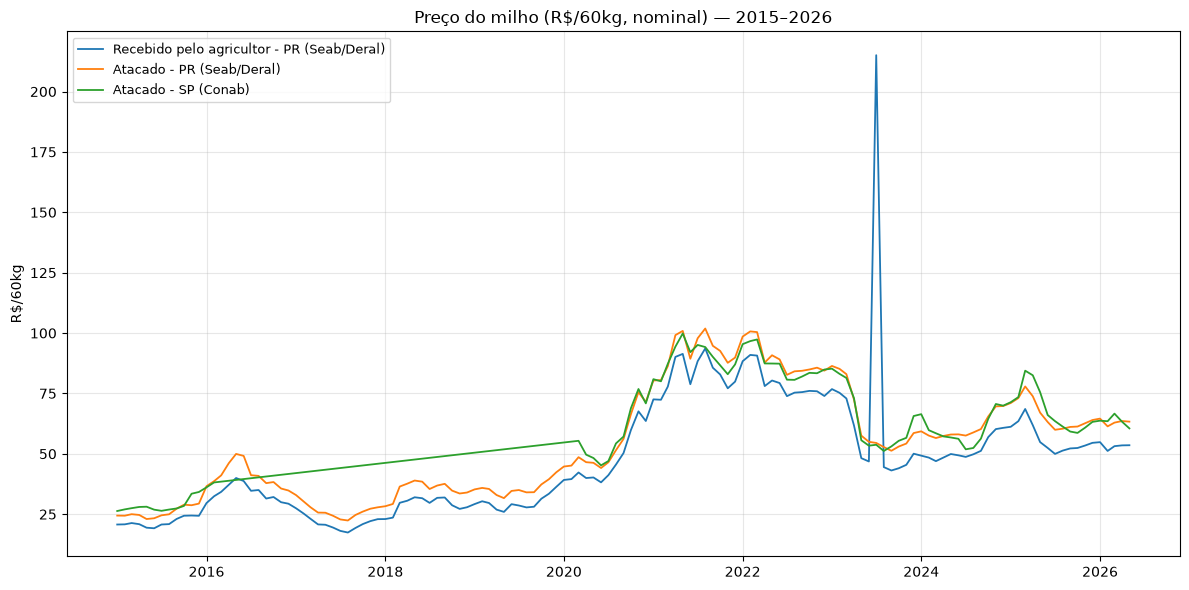

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
for codigo, rotulo in SERIES_IPEA.items():
    serie = precos_ipea[precos_ipea["sercodigo"] == codigo].sort_values(["ano", "mes"])
    serie = serie[serie["ano"] >= 2015]
    datas = pd.to_datetime(serie["ano"].astype(str) + "-" + serie["mes"].astype(str) + "-01")
    ax.plot(datas, serie["valor"], label=rotulo, linewidth=1.3)
ax.set_title("Preço do milho (R$/60kg, nominal) — 2015–2026")
ax.set_ylabel("R$/60kg")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 2. Correção monetária (IPCA) da série principal

Mesma metodologia do notebook `07`: busca a série 433 do SGS/Banco Central (com fallback pro cache
local `ipca_anual.csv`), deflaciona para R$ de 2025.

In [4]:
URL_BCB = (
    "https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados"
    "?formato=json&dataInicial=01/01/1999&dataFinal=31/12/2025"
)
CACHE_IPCA_ANUAL = Path("ipca_anual.csv")
ANO_BASE = 2025


def montar_indice_ipca_anual():
    try:
        with urllib.request.urlopen(URL_BCB, timeout=10) as resp:
            dados = json.load(resp)
        ipca = pd.DataFrame(dados)
        ipca["data"] = pd.to_datetime(ipca["data"], format="%d/%m/%Y")
        ipca["valor"] = ipca["valor"].astype(float)
        ipca = ipca.sort_values("data").reset_index(drop=True)
        indice = [100.0]
        for v in ipca["valor"]:
            indice.append(indice[-1] * (1 + v / 100))
        ipca["indice"] = indice[1:]
        ipca["ano"] = ipca["data"].dt.year
        anual = ipca.groupby("ano")["indice"].mean().rename("indice_medio").reset_index()
        print("IPCA obtido ao vivo da API do Banco Central (série 433).")
    except Exception as exc:
        print(f"Falha ao buscar IPCA ao vivo ({exc!r}); usando cache local {CACHE_IPCA_ANUAL}.")
        anual = pd.read_csv(CACHE_IPCA_ANUAL)
    return anual


ipca_anual = montar_indice_ipca_anual()
indice_base = ipca_anual.loc[ipca_anual["ano"] == ANO_BASE, "indice_medio"].iloc[0]
ipca_anual["fator_deflator"] = indice_base / ipca_anual["indice_medio"]
ipca_anual.tail(8)

IPCA obtido ao vivo da API do Banco Central (série 433).


,ano,indice_medio,fator_deflator
19,2018,344.676014,1.452610
20,2019,357.542908,1.400335
21,2020,369.025724,1.356762
22,2021,399.660666,1.252763
23,2022,436.748922,1.146379
24,2023,456.811114,1.096033
25,2024,476.761965,1.050168
26,2025,500.679944,1.000000


## 3. Série anual de referência (1999–2025) — mesma janela do custo (DERAL, série milho safrinha)

Média anual do preço mensal recebido pelo agricultor (R$/60kg e R$/kg), nominal e deflacionado para
R$ de 2025, restrita a 1999–2025 (mesma janela da série de custo SEAB/DERAL usada no notebook `09`).

In [5]:
preco_agricultor = precos_ipea[precos_ipea["sercodigo"] == "DERAL12_PRMI12"]

preco_anual = (
    preco_agricultor.groupby("ano")["valor"]
    .mean()
    .rename("preco_rs_60kg_nominal")
    .reset_index()
)
preco_anual = preco_anual.merge(ipca_anual[["ano", "fator_deflator"]], on="ano", how="left")
preco_anual["preco_rs_60kg_real"] = preco_anual["preco_rs_60kg_nominal"] * preco_anual["fator_deflator"]
preco_anual["preco_rs_kg_real"] = preco_anual["preco_rs_60kg_real"] / 60

preco_anual_1999_2025 = preco_anual[(preco_anual["ano"] >= 1999) & (preco_anual["ano"] <= 2025)].reset_index(drop=True)
preco_anual_1999_2025

,ano,preco_rs_60kg_nominal,fator_deflator,preco_rs_60kg_real,preco_rs_kg_real
0,1999,8.806667,4.776734,42.067102,0.701118
1,2000,10.805833,4.462405,48.220008,0.803667
2,2001,8.458333,4.176699,35.327915,0.588799
3,2002,14.369167,3.851268,55.339512,0.922325
4,2003,15.728283,3.357265,52.804011,0.880067
5,2004,15.526333,3.149463,48.899615,0.814994
6,2005,14.348583,2.946999,42.285260,0.704754
7,2006,12.593042,2.828656,35.621384,0.593690
8,2007,17.527408,2.729274,47.837092,0.797285
9,2008,19.039500,2.582624,49.171877,0.819531


## 4. Checagem cruzada com a CONAB (granularidade municipal, janela recente)

O arquivo de download da CONAB por município não tem série histórica longa (só 2025–2026), mas dá
pra conferir se o preço "recebido pelo produtor" bate com a média estadual do IPEA/DERAL nos meses
recentes em comum — inclusive cidades do Oeste do PR não cobertas pelo IPEA (que é estadual).

In [6]:
CACHE_CONAB_MUN = Path("conab_precos_municipio_milho.csv")
URL_CONAB_MUN = "https://portaldeinformacoes.conab.gov.br/downloads/arquivos/PrecosMensalMunicipio.txt"


def montar_precos_conab_municipio():
    try:
        with urllib.request.urlopen(URL_CONAB_MUN, timeout=30) as resp:
            precos = pd.read_csv(resp, sep=";", encoding="latin1", low_memory=False)
        for c in ["produto", "classificao_produto", "nom_municipio", "uf", "regiao", "dsc_nivel_comercializacao"]:
            precos[c] = precos[c].str.strip()
        precos = precos[precos["produto"] == "MILHO"].copy()
        print("Preços municipais obtidos ao vivo da CONAB.")
    except Exception as exc:
        print(f"Falha ao buscar CONAB ao vivo ({exc!r}); usando cache local {CACHE_CONAB_MUN}.")
        precos = pd.read_csv(CACHE_CONAB_MUN)
    precos["valor_produto_kg"] = (
        precos["valor_produto_kg"].astype(str).str.replace(",", ".", regex=False).astype(float)
    )
    return precos


conab_milho = montar_precos_conab_municipio()
conab_milho_pr_produtor = conab_milho[
    (conab_milho["uf"] == "PR") & (conab_milho["dsc_nivel_comercializacao"] == "PREÇO RECEBIDO P/ PRODUTOR")
].copy()

media_conab_mensal = conab_milho_pr_produtor.groupby(["ano", "mes"])["valor_produto_kg"].mean() * 60
media_ipea_mesmo_periodo = preco_agricultor.set_index(["ano", "mes"])["valor"]

comparacao = pd.DataFrame({
    "conab_media_municipios_pr": media_conab_mensal,
    "ipea_deral_pr": media_ipea_mesmo_periodo,
}).dropna()
comparacao["diferenca_%"] = 100 * (comparacao["conab_media_municipios_pr"] / comparacao["ipea_deral_pr"] - 1)
comparacao.round(2)

Preços municipais obtidos ao vivo da CONAB.


conab_media_municipios_pr  ipea_deral_pr  diferenca_%
ano  mes                                                       
2025 7                        50.86          49.96         1.80
     8                        52.38          51.32         2.06
     9                        52.94          52.23         1.36
     10                       53.35          52.42         1.78
     11                       54.00          53.44         1.06
     12                       55.43          54.55         1.62

In [7]:
cidades_pr_conab = sorted(conab_milho_pr_produtor["nom_municipio"].unique())
print(f"Municípios do PR com preço na CONAB (janela recente): {len(cidades_pr_conab)}")
print(cidades_pr_conab)

Municípios do PR com preço na CONAB (janela recente): 13
['CAMPO MOURÃO-PR', 'CASCAVEL-PR', 'CORNÉLIO PROCÓPIO-PR', 'GUARAPUAVA-PR', 'IRATI-PR', 'LAPA-PR', 'LONDRINA-PR', 'MARINGÁ-PR', 'PATO BRANCO-PR', 'PONTA GROSSA-PR', 'UBIRATÃ-PR', 'UMUARAMA-PR', 'UNIÃO DA VITÓRIA-PR']


## 5. Exportação

Série anual (1999–2025) pronta para juntar com o custo SEAB/DERAL (notebook `09`) na classificação
de risco econômico.

In [8]:
preco_anual_1999_2025.to_csv("precos_milho_pr.csv", index=False, encoding="utf-8-sig")
print("Arquivo gerado: precos_milho_pr.csv")

Arquivo gerado: precos_milho_pr.csv
